In [198]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("dados_matriculas.xlsx")

print(df.dtypes)

Mês           datetime64[us]
Matrículas             int64
dtype: object


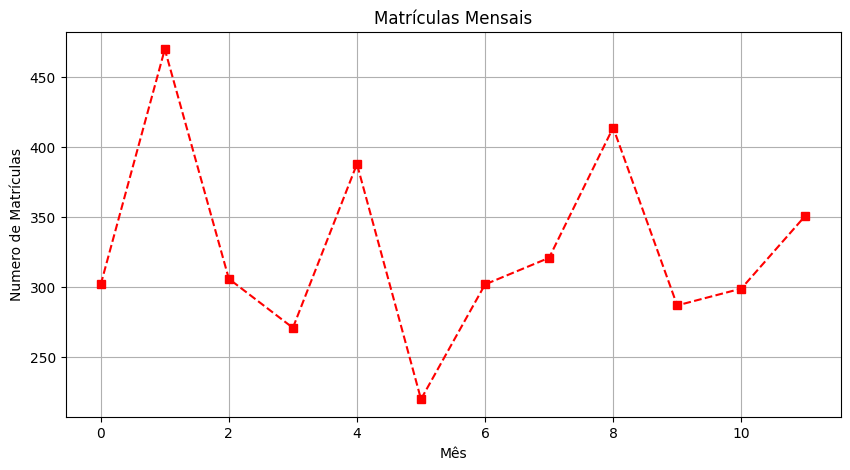

In [199]:
# Plotar o gráfico

plt.figure(figsize=(10,5))
df['Matrículas'].plot(marker='s', linestyle = '--', color='red')
plt.title("Matrículas Mensais")
plt.xlabel("Mês")
plt.ylabel("Numero de Matrículas")
plt.grid(True)

In [200]:
# Identificar os meses com menor e maior numero de matriculas

max_matriculas = df["Matrículas"].max()
mes_max_matriculas = df["Matrículas"].idxmax()
print(f"Mês com maior número de matrículas: {mes_max_matriculas}: {max_matriculas} matriculas")

min_matriculas = df["Matrículas"].min()
mes_min_matriculas = df["Matrículas"].idxmin()
print(f"Mês com menor numero de matriculas {mes_min_matriculas}: {min_matriculas} matrículas")


Mês com maior número de matrículas: 1: 470 matriculas
Mês com menor numero de matriculas 5: 220 matrículas


In [201]:
media_matriculas = df["Matrículas"].mean()

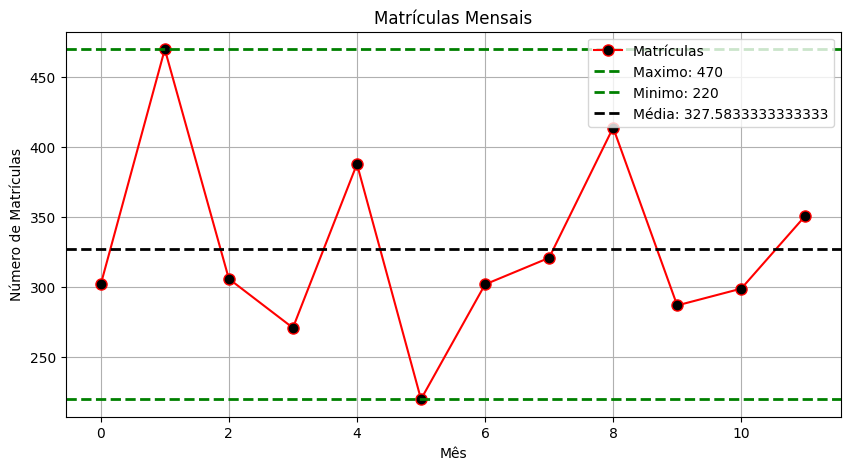

In [202]:
# Plotar o gráfico geral

plt.figure(figsize=(10,5))
df["Matrículas"].plot(marker='o', linestyle='-', color='red', label= 'Matrículas', mfc= 'black', markersize= '8')

# Adicionar linhas de info para máximo e mínimo de matricula

plt.axhline(y=max_matriculas, c= 'green', ls= '--', lw=2, label=f"Maximo: {max_matriculas}" )

plt.axhline(y=min_matriculas, color= 'green', linestyle='--', linewidth=2, label=f'Minimo: {min_matriculas}' )

plt.axhline(y=media_matriculas, color= 'black', linestyle= '--', linewidth=2, label=f"Média: {media_matriculas}" )

plt.legend()
plt.title("Matrículas Mensais")
plt.xlabel("Mês")
plt.ylabel("Número de Matrículas")
plt.grid(True)



Mês
2022-03-31    359.333333
2022-06-30    293.000000
2022-09-30    345.666667
2022-12-31    312.333333
Freq: QE-DEC, Name: Matrículas, dtype: float64


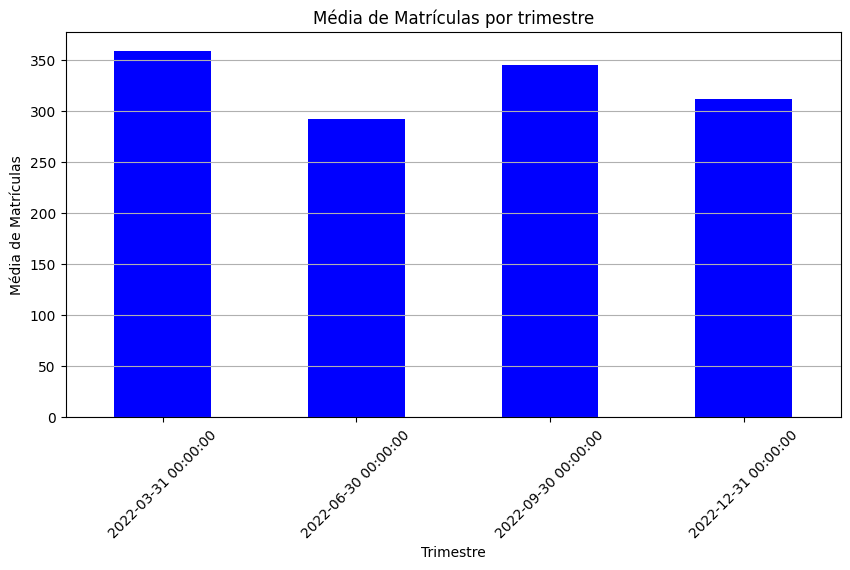

In [203]:
# --------------

# Tendência de Matriculas

# Calcular a medica de matriculas por trimestre
''''
QE = Trimestre

QS = Semestre

Q = Quadrimestre

A = Anual

D = Diário

W = Semanal 

M = Mensal

H = Horário
'''

# Passo 1 - Converter para datetime
df["Mês"] = pd.to_datetime(df["Mês"])

# Passo 2 - Definir a coluna de datas como índices
df.set_index("Mês", inplace=True)

# Passo 3 - Calcular média trimestral


matriculas_trimestre = df["Matrículas"].resample("QE").mean()
print(matriculas_trimestre)

# ---------------- # plotar gráfico de barras

plt.figure(figsize=(10,5))

matriculas_trimestre.plot(kind='bar', color= 'blue')
plt.title("Média de Matrículas por trimestre")
plt.xlabel("Trimestre")
plt.ylabel("Média de Matrículas")
plt.xticks(rotation=45)
plt.grid(axis='y')

In [204]:
# Variação percentual de matriculas

# Calculando a variacao percentual das matriculas de um mes para outro
# Identificar o periodo de maior crescimento e maior queda nas matrículas

df["Matrículas"].std() # Desvio padrão
df["Matrículas"] - df["Matrículas"].mean() # Desvio simples 

Mês
2022-01-31    -25.583333
2022-02-28    142.416667
2022-03-31    -21.583333
2022-04-30    -56.583333
2022-05-31     60.416667
2022-06-30   -107.583333
2022-07-31    -25.583333
2022-08-31     -6.583333
2022-09-30     86.416667
2022-10-31    -40.583333
2022-11-30    -28.583333
2022-12-31     23.416667
Name: Matrículas, dtype: float64

In [205]:
# 1. Calcular a variação percentual mensal
# df["Mês"] = pd.to_datetime(df["Mes])
# df.set_index("MES", inplace=True)

variacao_percentual = df["Matrículas"].pct_change() * 100
print(variacao_percentual)

# O metrodo .pct_change

Mês
2022-01-31          NaN
2022-02-28    55.629139
2022-03-31   -34.893617
2022-04-30   -11.437908
2022-05-31    43.173432
2022-06-30   -43.298969
2022-07-31    37.272727
2022-08-31     6.291391
2022-09-30    28.971963
2022-10-31   -30.676329
2022-11-30     4.181185
2022-12-31    17.391304
Name: Matrículas, dtype: float64


In [206]:
#Criar tabela com os resultados
 
tabela_variacao = pd.DataFrame({
    "Matrículas":df['Matrículas'],
    "Variação Percentual (%)": variacao_percentual
})
 
print(tabela_variacao.round(2))

            Matrículas  Variação Percentual (%)
Mês                                            
2022-01-31         302                      NaN
2022-02-28         470                    55.63
2022-03-31         306                   -34.89
2022-04-30         271                   -11.44
2022-05-31         388                    43.17
2022-06-30         220                   -43.30
2022-07-31         302                    37.27
2022-08-31         321                     6.29
2022-09-30         414                    28.97
2022-10-31         287                   -30.68
2022-11-30         299                     4.18
2022-12-31         351                    17.39


Mês
2022-01-31      NaN
2022-02-28    55.63
2022-03-31   -34.89
2022-04-30   -11.44
2022-05-31    43.17
2022-06-30   -43.30
2022-07-31    37.27
2022-08-31     6.29
2022-09-30    28.97
2022-10-31   -30.68
2022-11-30     4.18
2022-12-31    17.39
Name: Matrículas, dtype: float64


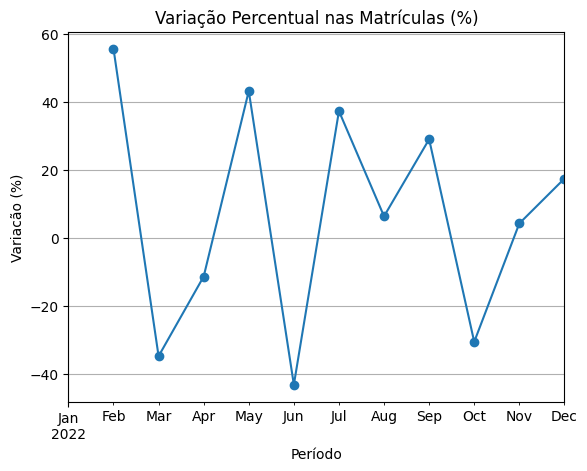

In [207]:
# Exibir a variaçao percentual com 2 casas decimais

print(variacao_percentual.round(2))

variacao_percentual.plot(marker='o', title='Variação Percentual nas Matrículas (%)')
plt.ylabel('Variacão (%)')
plt.xlabel('Período')
plt.grid(True)
plt.show()

In [208]:
%pip install jinja2

Note: you may need to restart the kernel to use updated packages.


In [209]:
# criar tabela

# 
import seaborn as sns

tabela_variacao = pd.DataFrame({
    "Matrículas":df['Matrículas'],
    "Variação Percentual (%)": variacao_percentual
}).round(2)
 
# Exibir a tabela formatada
def colorir_variacao(val):
    if val > 0:
        color = 'green' # Verde para crescimento
    elif val < 0:
        color = 'red' # Vermelho para queda
    else:
        color = 'blue' # Azul para valores sem alteraçao
    return f'color: {color}'

tabela_variacao.style.map(colorir_variacao, subset=['Variação Percentual (%)'])


,Matrículas,Variação Percentual (%)
Mês,,
2022-01-31 00:00:00,302,nan
2022-02-28 00:00:00,470,55.630000
2022-03-31 00:00:00,306,-34.890000
2022-04-30 00:00:00,271,-11.440000
2022-05-31 00:00:00,388,43.170000
2022-06-30 00:00:00,220,-43.300000
2022-07-31 00:00:00,302,37.270000
2022-08-31 00:00:00,321,6.290000
2022-09-30 00:00:00,414,28.970000


In [210]:
#3 identificar os meses com maior crescimento e maior queda
mes_maior_crescimento = variacao_percentual.idxmax() # Encontra o valor máximo de variação percentual
mes_maior_queda = variacao_percentual.idxmin() # Encontra o valor mínimo de variação percentual

print(f"Mes com maior crescimento: {mes_maior_crescimento}: {mes_maior_crescimento}%") # Imprime o mês com maior crescimento e o valor da variação percentual
print(f"Mes com maior queda:  {mes_maior_queda}%") # Imprime o mês com maior queda e o valor da variação percentual
 
 

Mes com maior crescimento: 2022-02-28 00:00:00: 2022-02-28 00:00:00%
Mes com maior queda:  2022-06-30 00:00:00%


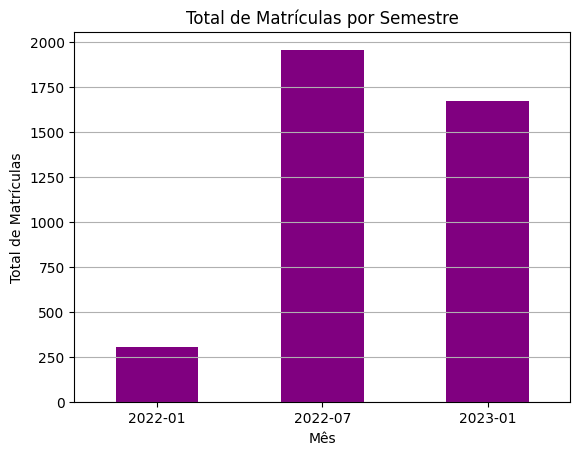

In [211]:
# 6ME Month End 
semestral = df["Matrículas"].resample("6ME").sum()
semestral.index = semestral.index.strftime('%Y-%m')
semestral.plot(kind='bar', color='purple')
plt.title("Total de Matrículas por Semestre")
plt.ylabel("Total de Matrículas")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()



In [212]:
media = df['Matrículas'].mean() # média

mediana = df['Matrículas'].median() # Mediana

moda = df['Matrículas'].mode().values[0] # Moda

desvio = df['Matrículas'].std() # desvio padrão

coef_var = desvio / media * 100 # Coeficiente de variacâo

print(f"Média: {media:.2f}")

print(f"Médiana: {mediana}")

print(f"Moda: {moda}")

print(f"Desvio padrão: {desvio:.2f}")

print(f"Coeficiente de variação: {coef_var:.2f}%")

if media > mediana: 
    print("Distribuição assimétrica à direita (positiva)")
elif media < mediana:
    print("Distribuiçâo assimétrica à esquerda (negativa)")
else:
    print("Distruibuição simétrica")

Média: 327.58
Médiana: 304.0
Moda: 302
Desvio padrão: 68.10
Coeficiente de variação: 20.79%
Distribuição assimétrica à direita (positiva)
